# 반응 부산물 예측: 스킴에서 예상 m/z 생성

합성 반응에서 **Product 외에 어떤 Byproduct가 생길 수 있는지** 예측하고,
실측 스펙트럼에서 해당 m/z가 존재하는지 확인합니다.

### 이 장의 한계

여기서 다루는 부산물 예측은 **단순한 반응 유형 기반**의 간소화된 모델입니다.
실제 유기합성에서는:
- 반응 메커니즘이 훨씬 복잡하고 (라디칼, 전이상태, 용매 효과 등)
- 예상하지 못한 부산물이 다수 생성되며
- 반응 조건(온도, 촉매, 농도)에 따라 부산물 분포가 크게 달라집니다

**이 장의 목적**은 정확한 부산물 예측이 아니라,
**"반응 스킴 → 예상 m/z → 실측 확인"이라는 분석 워크플로우 자체를 시연**하는 것입니다.
실제 분석에서는 문헌 기반의 부산물 DB나 판단이 필요합니다.

## 학습 목표
1. **반응 유형별 delta MW** — 반응식에서 질량 변화 계산
2. **Product MW 예측** — SM + 시약 + 반응 유형 → Product MW
3. **Byproduct 예측** — 반응 유형별 대표적 부산물
4. **Adduct pair 검증** — 동일 분자의 여러 adduct 동시 존재 확인
5. **실측 스펙트럼 탐색** — 예측된 m/z가 실제로 있는지

## 환경 설정
필요한 패키지를 설치하고 임포트합니다.

In [1]:
!pip install -q pyopenms scipy matplotlib numpy pandas openpyxl


### 패키지 로드
- **pyopenms**: mzML 데이터 로드
- **numpy/pandas**: 수치 계산 및 데이터 처리

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyopenms as oms
import os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
print('준비 완료.')

---
## 1. 반응 유형별 질량 변화

유기합성 반응은 **원자의 재배열**입니다. 반응 전후 질량 변화(delta MW)는 반응 유형으로 결정됩니다.

| 반응 유형 | 반응식 | Delta MW |
|-----------|--------|----------|
| Amide Coupling | R-COOH + H2N-R' → R-CONH-R' + H2O | SM + Reagent **- 18.01** |
| Suzuki Coupling | Ar-X + Ar'-B(OH)2 → Ar-Ar' | SM - LG + Reagent - B(OH)2 |
| Buchwald-Hartwig | Ar-X + HNR2 → Ar-NR2 + HX | SM - LG + Reagent - H |
| SNAr | Ar-X + NuH → Ar-Nu + HX | SM - LG + Reagent - H |
| Reductive Amination | R-CHO + H2N-R' → R-CH2-NH-R' | SM + Reagent - O + 2H |
| Boc Deprotection | R-NHBoc → R-NH2 | SM **- 100.05** |
| Cbz Deprotection | R-NHCbz → R-NH2 | SM **- 134.04** |
| Click (CuAAC) | R-N3 + R'-CCH → triazole | SM + Reagent (± 0) |

### 이탈기(Leaving Group) 질량
Suzuki, Buchwald-Hartwig 등에서는 이탈기에 따라 delta MW가 달라집니다.

| 이탈기 | 질량 (Da) |
|--------|----------|
| Br | 78.918 |
| Cl | 34.969 |
| I | 126.905 |
| F | 18.998 |
| OTf | 148.952 |

In [ ]:
# 반응 유형 데이터베이스
REACTION_TYPES = {
    'amide_coupling': {
        'name': 'Amide Coupling (HATU/EDC)',
        'equation': 'R-COOH + H2N-R\' -> R-CONH-R\' + H2O',
        'delta_mw': -18.0106,
        'needs_reagent': True,
    },
    'suzuki': {
        'name': 'Suzuki Coupling',
        'equation': 'Ar-X + Ar\'-B(OH)2 -> Ar-Ar\'',
        'delta_mw': None,  # depends on leaving group
        'needs_reagent': True,
        'leaving_groups': {'Br': 78.9183, 'Cl': 34.9689, 'I': 126.9045, 'OTf': 148.9520},
        'boronic_acid_loss': 45.0148,
    },
    'buchwald_hartwig': {
        'name': 'Buchwald-Hartwig Amination',
        'equation': 'Ar-X + H-NR2 -> Ar-NR2 + HX',
        'delta_mw': None,
        'needs_reagent': True,
        'leaving_groups': {'Br': 78.9183, 'Cl': 34.9689, 'I': 126.9045},
    },
    'snar': {
        'name': 'SNAr',
        'equation': 'Ar-X + Nu-H -> Ar-Nu + HX',
        'delta_mw': None,
        'needs_reagent': True,
        'leaving_groups': {'F': 18.9984, 'Cl': 34.9689, 'NO2': 45.9929},
    },
    'reductive_amination': {
        'name': 'Reductive Amination',
        'equation': 'R-CHO + H2N-R\' -> R-CH2-NH-R\'',
        'delta_mw': -15.9949,  # -O +2H
        'needs_reagent': True,
    },
    'boc_deprotection': {
        'name': 'Boc Deprotection',
        'equation': 'R-NHBoc -> R-NH2 + CO2 + isobutylene',
        'delta_mw': -100.0524,
        'needs_reagent': False,
    },
    'cbz_deprotection': {
        'name': 'Cbz Deprotection',
        'equation': 'R-NHCbz -> R-NH2 + CO2 + toluene',
        'delta_mw': -134.0368,
        'needs_reagent': False,
    },
    'click_chem': {
        'name': 'CuAAC Click Chemistry',
        'equation': 'R-N3 + R\'-CCH -> triazole',
        'delta_mw': 0.0,
        'needs_reagent': True,
    },
}

print(f"{'Reaction':25s} {'Needs Reagent':>13s} {'Delta MW':>10s}")
print('-' * 52)
for key, rxn in REACTION_TYPES.items():
    delta = f'{rxn["delta_mw"]:.4f}' if rxn['delta_mw'] is not None else 'varies'
    print(f"{rxn['name']:25s} {str(rxn['needs_reagent']):>13s} {delta:>10s}")

---
## 2. Product MW 예측

SM MW + 시약 MW + 반응 유형 → **Product의 정확한 MW**를 계산합니다.

In [ ]:
H_MASS = 1.00783  # hydrogen atom

def predict_product_mw(sm_mw, reaction_type, reagent_mw=0.0, leaving_group='Br'):
    """반응 유형 + SM MW + 시약 MW -> Product MW"""
    rxn = REACTION_TYPES.get(reaction_type)
    if rxn is None:
        return None
    
    if reaction_type == 'suzuki':
        lg = rxn['leaving_groups'].get(leaving_group, 78.9183)
        return round(sm_mw - lg + reagent_mw - rxn['boronic_acid_loss'], 4)
    
    elif reaction_type in ('buchwald_hartwig', 'snar', 'alkylation'):
        lg = rxn['leaving_groups'].get(leaving_group, 78.9183)
        return round(sm_mw - lg + reagent_mw - H_MASS, 4)
    
    elif reaction_type == 'reductive_amination':
        return round(sm_mw + reagent_mw - 18.0106 + 2.0157, 4)
    
    elif reaction_type in ('amide_coupling', 'click_chem'):
        return round(sm_mw + reagent_mw + rxn['delta_mw'], 4)
    
    elif rxn['delta_mw'] is not None and not rxn['needs_reagent']:
        return round(sm_mw + rxn['delta_mw'], 4)
    
    return None

# 예시: Amide Coupling
sm_mw = 137.0477  # 4-aminobenzoic acid (C7H7NO2)
reagent_mw = 93.0578  # aniline (C6H7N)

product_mw = predict_product_mw(sm_mw, 'amide_coupling', reagent_mw)
print(f'Amide Coupling 예시:')
print(f'  SM:      MW = {sm_mw:.4f} Da')
print(f'  Reagent: MW = {reagent_mw:.4f} Da')
print(f'  Product: MW = {product_mw:.4f} Da')
print(f'  Delta:   {product_mw - sm_mw:.4f} Da')

# 여러 반응 유형 비교
print(f'\n{"Reaction":25s} {"Product MW":>12s} {"Delta":>10s}')
print('-' * 50)
for rtype in ['amide_coupling', 'suzuki', 'buchwald_hartwig', 'reductive_amination', 'boc_deprotection']:
    pmw = predict_product_mw(sm_mw, rtype, reagent_mw, 'Br')
    if pmw:
        print(f"{REACTION_TYPES[rtype]['name']:25s} {pmw:12.4f} {pmw - sm_mw:+10.4f}")

---
## 3. Byproduct 예측

각 반응 유형에는 **대표적인 부산물**이 있습니다.  
이를 미리 예측해서 스펙트럼에서 찾으면, 반응 경로를 해석할 수 있습니다. (* 단분자인 경우 예측이 간단하지만, 분자가 커질수록 예측의 정확도가 중요합니다.) 

| 반응 | 대표 부산물 | 발생 원인 |
|------|-----------|----------|
| Suzuki | Proto-dehalogenation (SM-H) | 이탈기가 H로 치환 |
| Suzuki | SM homo-coupling | SM끼리 결합 |
| Buchwald | Dehalogenation (Ar-H) | 환원적 탈할로겐 |
| Buchwald | Bis-arylation | 이중 아릴화 |
| Amide | Symmetric anhydride | 산무수물 형성 |
| Red. Amin. | Over-alkylation | 3차 아민 |
| Red. Amin. | Aldehyde reduction | 알데히드 → 알코올 |

In [ ]:
PROTON = 1.00728  # proton (for m/z calculation)

def predict_byproducts(sm_mw, reaction_type, reagent_mw=0.0, leaving_group='Br'):
    """반응 유형별 예상 byproduct MW + m/z 목록"""
    rxn = REACTION_TYPES.get(reaction_type)
    if rxn is None:
        return []
    
    byproducts = []
    
    if reaction_type == 'suzuki':
        lg = rxn['leaving_groups'].get(leaving_group, 78.9183)
        # Proto-dehalogenation
        dehal_mw = sm_mw - lg + H_MASS
        byproducts.append({'name': 'Proto-dehalogenation (SM-X -> SM-H)',
                          'mw': round(dehal_mw, 4), 'likelihood': 'high'})
        # SM homo-coupling
        homo_mw = 2 * (sm_mw - lg)
        byproducts.append({'name': 'SM Homo-coupling',
                          'mw': round(homo_mw, 4), 'likelihood': 'medium'})
        # Reagent homo-coupling
        if reagent_mw > 0:
            r_homo = 2 * (reagent_mw - rxn['boronic_acid_loss'])
            byproducts.append({'name': 'Reagent Homo-coupling',
                              'mw': round(r_homo, 4), 'likelihood': 'medium'})
    
    elif reaction_type in ('buchwald_hartwig', 'snar'):
        lg = rxn['leaving_groups'].get(leaving_group, 78.9183)
        dehal_mw = sm_mw - lg + H_MASS
        byproducts.append({'name': 'Dehalogenation (Ar-X -> Ar-H)',
                          'mw': round(dehal_mw, 4), 'likelihood': 'high'})
        if reagent_mw > 0 and reaction_type == 'buchwald_hartwig':
            bis_mw = 2 * (sm_mw - lg) + reagent_mw - 2 * H_MASS
            byproducts.append({'name': 'Bis-arylation',
                              'mw': round(bis_mw, 4), 'likelihood': 'medium'})
    
    elif reaction_type == 'amide_coupling':
        byproducts.append({'name': 'Unreacted SM (hydrolysis)',
                          'mw': round(sm_mw, 4), 'likelihood': 'high'})
        anhydride_mw = 2 * sm_mw - 18.0106
        byproducts.append({'name': 'Symmetric anhydride',
                          'mw': round(anhydride_mw, 4), 'likelihood': 'low'})
    
    elif reaction_type == 'reductive_amination':
        if reagent_mw > 0:
            over_mw = sm_mw + 2 * reagent_mw - 2 * 18.0106 + 2 * 2.0157
            byproducts.append({'name': 'Over-alkylation (tertiary amine)',
                              'mw': round(over_mw, 4), 'likelihood': 'medium'})
        alcohol_mw = sm_mw + 2.0157
        byproducts.append({'name': 'Aldehyde reduction (R-CHO -> R-CH2OH)',
                          'mw': round(alcohol_mw, 4), 'likelihood': 'medium'})
    
    # Add [M+H]+ m/z for all
    for bp in byproducts:
        bp['mz_pos'] = round(bp['mw'] + PROTON, 4)
        bp['mz_neg'] = round(bp['mw'] - PROTON, 4)
    
    return byproducts

# 예시: Suzuki coupling 부산물 예측
sm_mw_suzuki = 250.0  # 예시 SM
reagent_mw_suzuki = 150.0  # 예시 boronic acid

product_mw_sz = predict_product_mw(sm_mw_suzuki, 'suzuki', reagent_mw_suzuki, 'Br')
byproducts_sz = predict_byproducts(sm_mw_suzuki, 'suzuki', reagent_mw_suzuki, 'Br')

print(f'=== Suzuki Coupling 예측 ===')
print(f'SM MW: {sm_mw_suzuki:.4f}, Reagent MW: {reagent_mw_suzuki:.4f}')
print(f'Product MW: {product_mw_sz:.4f} -> [M+H]+ = {product_mw_sz + PROTON:.4f}')
print(f'\nPredicted Byproducts:')
for bp in byproducts_sz:
    print(f'  [{bp["likelihood"]:6s}] {bp["name"]:40s} MW={bp["mw"]:.4f}  [M+H]+={bp["mz_pos"]:.4f}')

### 예측 m/z 맵 시각화

- SM, Product, Byproduct의 예측 m/z를 한 그래프에 표시
- 각 화합물의 adduct별 m/z 위치를 스틱 플롯으로 시각화
- 실측 스펙트럼과 대조할 때 참고 자료로 활용

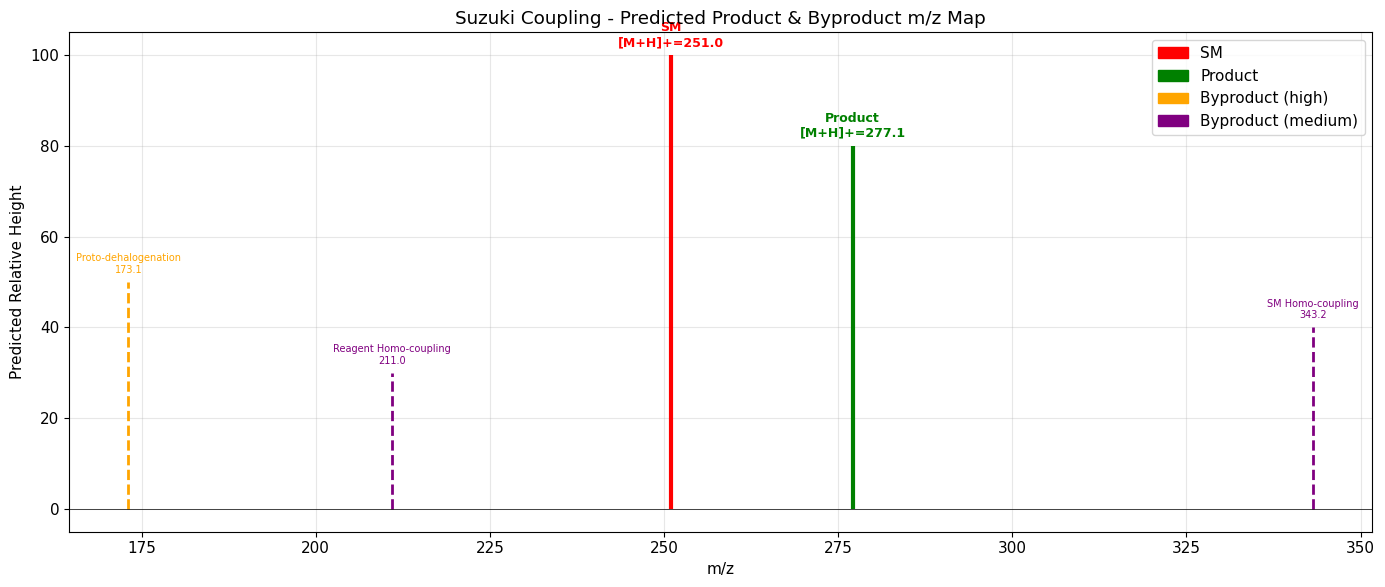

In [1]:
# 시각화: 예측된 모든 화합물의 m/z 맵
fig, ax = plt.subplots(figsize=(14, 6))

# SM
ax.vlines(sm_mw_suzuki + PROTON, 0, 100, colors='red', linewidth=3)
ax.text(sm_mw_suzuki + PROTON, 102, f'SM\n[M+H]+={sm_mw_suzuki+PROTON:.1f}',
       ha='center', fontsize=9, color='red', fontweight='bold')

# Product
ax.vlines(product_mw_sz + PROTON, 0, 80, colors='green', linewidth=3)
ax.text(product_mw_sz + PROTON, 82, f'Product\n[M+H]+={product_mw_sz+PROTON:.1f}',
       ha='center', fontsize=9, color='green', fontweight='bold')

# Byproducts
colors_bp = {'high': 'orange', 'medium': 'purple', 'low': 'gray'}
for i, bp in enumerate(byproducts_sz):
    c = colors_bp[bp['likelihood']]
    h = 50 - i * 10
    ax.vlines(bp['mz_pos'], 0, h, colors=c, linewidth=2, linestyle='--')
    ax.text(bp['mz_pos'], h + 2,
           f"{bp['name'].split('(')[0].strip()}\n{bp['mz_pos']:.1f}",
           ha='center', fontsize=7, color=c)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('m/z')
ax.set_ylabel('Predicted Relative Height')
ax.set_title('Suzuki Coupling - Predicted Product & Byproduct m/z Map')
ax.grid(alpha=0.3)

from matplotlib.patches import Patch
legend = [Patch(color='red', label='SM'), Patch(color='green', label='Product'),
          Patch(color='orange', label='Byproduct (high)'),
          Patch(color='purple', label='Byproduct (medium)')]
ax.legend(handles=legend, loc='upper right')
plt.tight_layout()
plt.show()

---
## 4. Adduct Pair 검증

하나의 분자가 여러 adduct로 나타나면, **adduct 간 질량 차이**가 일정합니다.  
이 패턴을 찾으면 분자의 존재를 강력히 확인할 수 있습니다.

| Pair | Delta m/z (Da) | 의미 |
|------|---------------|------|
| [M+H]+ / [M+Na]+ | 21.982 | Na가 H 대체 |
| [M+H]+ / [M+K]+ | 37.956 | K가 H 대체 |
| [M+H]+ / [M+NH4]+ | 17.027 | NH4가 H 대체 |
| [M+Na]+ / [M+K]+ | 15.974 | K가 Na 대체 |
| [M+H]+ / [M+H-H2O]+ | -18.011 | 탈수 |

In [ ]:
ADDUCT_PAIR_DELTAS = [
    ('H_Na',   21.9819, '[M+H]+ / [M+Na]+'),
    ('H_K',    37.9559, '[M+H]+ / [M+K]+'),
    ('H_NH4',  17.0271, '[M+H]+ / [M+NH4]+'),
    ('H_H2O', -18.0106, '[M+H]+ / [M+H-H2O]+'),
    ('Na_K',   15.9739, '[M+Na]+ / [M+K]+'),
]

def find_adduct_pairs(mz_array, int_array, mz_tolerance=0.02):
    """스펙트럼에서 adduct pair 찾기"""
    pairs = []
    n = len(mz_array)
    for i in range(n):
        for j in range(i + 1, n):
            delta = mz_array[j] - mz_array[i]
            for pair_name, expected_delta, desc in ADDUCT_PAIR_DELTAS:
                if abs(delta - expected_delta) <= mz_tolerance:
                    predicted_mw = mz_array[i] - PROTON
                    pairs.append({
                        'pair': desc,
                        'mz_1': round(float(mz_array[i]), 4),
                        'mz_2': round(float(mz_array[j]), 4),
                        'delta': round(float(delta), 4),
                        'predicted_mw': round(float(predicted_mw), 4),
                    })
    return pairs

print('Adduct pair 탐색 함수 정의 완료.')

---
## 5. 실측 데이터에서 검증 (Adduct + In-Source Fragment)

TOF-MS 데이터를 로드하고, 예측된 부산물의 m/z가 **실제 스펙트럼에 존재하는지** 확인합니다.

### 왜 Fragment 이온도 함께 탐색하는가?

부산물의 precursor ion이 스펙트럼에서 약하거나 안 보일 수 있습니다.
이온원에서 분자가 깨지면 precursor 대신 **fragment ion이 더 강하게** 나타나는 경우가 있기 때문입니다.

- 부산물 X의 [M-H]⁻가 안 보여도, **-NO loss fragment**는 보일 수 있음
- Precursor만 찾으면 → 실제로 존재하는 부산물을 **"없다"고 오판**
- Fragment까지 찾으면 → 부산물 검출 성공률이 크게 향상

따라서 아래 탐색에서는 각 화합물의 **adduct + neutral loss fragment**를 모두 찾습니다.

> **참고**: fragment 면적을 합산하여 정확한 정량을 하는 것은 [05 Integration](06%20Summation%20Integration.ipynb)에서 다룹니다.
> 이 장에서는 부산물의 **존재 여부 확인(detection)**에 초점을 둡니다.

### mzML 데이터 로드 및 대표 스펙트럼 추출

- TOF-MS 데이터를 로드하고 TIC 피크 시점의 mass spectrum을 추출
- 이 스펙트럼에서 예측된 m/z가 실제로 존재하는지 확인

In [ ]:
import os, pyopenms as oms

exp = oms.MSExperiment()
oms.MzMLFile().load('echo-tof-colab/data/mzml/20260330_TOFMS.mzML', exp)
print(f'로드 완료: {exp.getNrSpectra()} spectra')

# TIC 최대 시점 스펙트럼
best_spec = max((s for s in exp if s.getMSLevel() == 1),
                key=lambda s: sum(s.get_peaks()[1]))
mz_data, int_data = best_spec.get_peaks()
print(f'스펙트럼: RT={best_spec.getRT()/60:.3f} min, {len(mz_data)} ions')


### 통합 자동 탐색: Adduct + ISF Fragment

각 화합물에 대해 3단계로 존재 여부를 자동 판정합니다:

1. **Adduct 탐색**: [M-H]⁻, [M+CH₃COO]⁻, [M+Cl]⁻ 등 모든 adduct m/z를 스펙트럼에서 탐색
2. **ISF Fragment 탐색**: [M-H]⁻ 기준으로 -NO, -NO₂, -H₂O, -CO neutral loss fragment 탐색
3. **자동 판정**: 매칭된 이온 수에 따라 CONFIRMED / PROBABLE / NOT FOUND 판정

```
for compound in compounds:
    # 1. adduct m/z 계산 → 스펙트럼에서 찾기
    # 2. ISF fragment m/z 계산 → 스펙트럼에서 찾기
    # 3. 총 매칭 수 → 판정
    #    ≥ 3개 → CONFIRMED
    #    1~2개 → PROBABLE
    #    0개  → NOT FOUND
```

In [ ]:
# 통합 자동 탐색: Adduct + ISF Fragment + 판정

NEUTRAL_LOSSES = {
    'NO':  29.9974, 'NO2': 45.9929,
    'H2O': 18.0106, 'CO':  27.9949,
}

COMPOUNDS = {
    'TNT':      {'mw': 227.0178, 'formula': 'C7H5N3O6'},
    'RDX':      {'mw': 222.0294, 'formula': 'C3H6N6O6'},
    'HMX':      {'mw': 296.0465, 'formula': 'C4H8N8O8'},
    '2,4-DNT':  {'mw': 182.0328, 'formula': 'C7H6N2O4'},
    'Tetryl':   {'mw': 287.0139, 'formula': 'C7H5N5O8'},
    '4-Am-DNT': {'mw': 197.0437, 'formula': 'C7H7N3O4'},
}

# Adduct shifts (ion mass, NOT ion - proton)
ADDUCTS_NEG = [
    ('[M-H]-',       -PROTON),
    ('[M+CH3COO]-',  59.0133),   # acetate ion
    ('[M+HCOO]-',    44.9977),   # formate ion
    ('[M+Cl]-',      34.9689),   # chloride ion
]

def find_peak(mz_arr, int_arr, target_mz, tol_ppm=20):
    tol_da = target_mz * tol_ppm * 1e-6
    mask = (mz_arr >= target_mz - tol_da) & (mz_arr <= target_mz + tol_da)
    if not np.any(mask):
        return None, None
    idx = np.argmax(int_arr[mask])
    return float(mz_arr[mask][idx]), float(int_arr[mask][idx])

# 통합 탐색 실행
all_results = {}

for name, info in COMPOUNDS.items():
    mw = info['mw']
    found_ions = []
    
    # Step 1: Adduct 탐색
    for adduct_name, shift in ADDUCTS_NEG:
        pred_mz = mw + shift
        found_mz, found_int = find_peak(mz_data, int_data, pred_mz)
        if found_mz is not None:
            found_ions.append({'type': 'adduct', 'name': adduct_name,
                               'pred': pred_mz, 'obs': found_mz, 'int': found_int})
    
    # Step 2: ISF Fragment 탐색 (from [M-H]-)
    base_mz = mw - PROTON  # [M-H]-
    for loss_name, loss_mass in NEUTRAL_LOSSES.items():
        frag_mz = base_mz - loss_mass
        if frag_mz > 50:
            found_mz, found_int = find_peak(mz_data, int_data, frag_mz)
            if found_mz is not None:
                found_ions.append({'type': 'ISF', 'name': f'-{loss_name}',
                                   'pred': frag_mz, 'obs': found_mz, 'int': found_int})
    
    # Step 3: 판정
    n = len(found_ions)
    verdict = 'CONFIRMED' if n >= 3 else 'PROBABLE' if n >= 1 else 'NOT FOUND'
    all_results[name] = {'ions': found_ions, 'verdict': verdict}
    
    # 출력
    print(f'\n{name} ({info["formula"]}) — {verdict} ({n} ions matched)')
    for ion in found_ions:
        ppm = (ion['obs'] - ion['pred']) / ion['pred'] * 1e6
        print(f'  {ion["type"]:6s} {ion["name"]:15s} pred={ion["pred"]:.4f} obs={ion["obs"]:.4f} '
              f'ppm={ppm:+.1f} int={ion["int"]:.0f}')


### 검출 현황 시각화

- 각 화합물별로 어떤 adduct가 검출되었는지 한눈에 확인
- 여러 adduct가 동시에 검출되면 동정 신뢰도가 높아짐

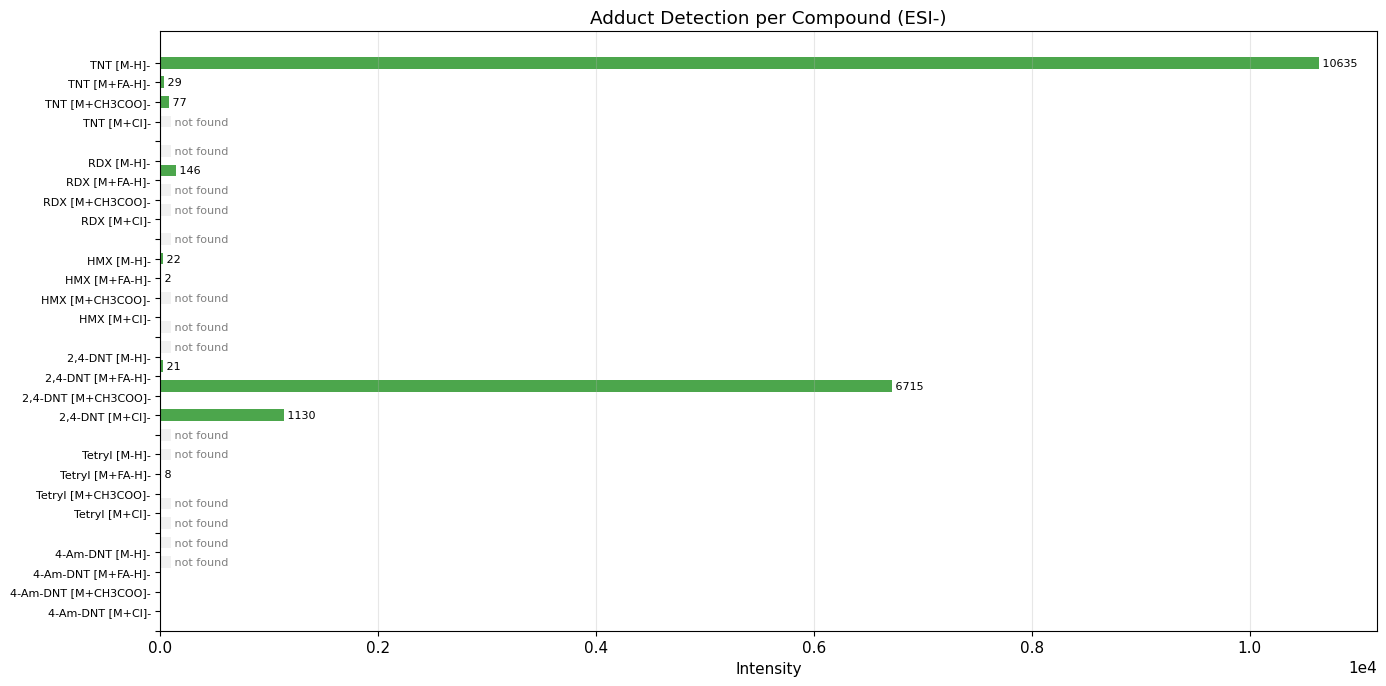

In [2]:
# 시각화: 각 화합물의 adduct 검출 현황
fig, ax = plt.subplots(figsize=(14, 7))

y_pos = 0
y_labels = []
colors_found = {'found': 'green', 'missing': 'lightgray'}

for name, info in COMPOUNDS.items():
    mw = info['mw']
    for adduct_name, charge, shift in ADDUCTS_NEG:
        pred_mz = (mw + shift) / abs(charge)
        found_mz, found_int = find_peak(mz_data, int_data, pred_mz)
        
        if found_int is not None:
            ax.barh(y_pos, found_int, color='green', alpha=0.7, height=0.6)
            ax.text(found_int, y_pos, f' {found_int:.0f}', va='center', fontsize=8)
        else:
            ax.barh(y_pos, 100, color='lightgray', alpha=0.3, height=0.6)
            ax.text(100, y_pos, ' not found', va='center', fontsize=8, color='gray')
        
        y_labels.append(f'{name} {adduct_name}')
        y_pos += 1
    y_pos += 0.5  # gap between compounds
    y_labels.append('')

ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=8)
ax.set_xlabel('Intensity')
ax.set_title('Adduct Detection per Compound (ESI-)')
ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
ax.grid(alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Summary

| Step | 입력 | 출력 | 목적 |
|------|------|------|------|
| Product MW | SM + 시약 + 반응 유형 | Product 정확 질량 | 생성물 예측 |
| Byproduct | 반응 유형 + SM | 부산물 MW 목록 | 부반응 예측 |
| Adduct pair | 스펙트럼 피크 쌍 | delta m/z 매칭 | 분자 존재 확인 |
| Multi-adduct | 화합물 MW → 여러 adduct | CONFIRMED/PROBABLE | 동정 신뢰도 |

### 핵심 포인트
- 반응 유형만 알면 **Product + Byproduct의 m/z를 사전에 예측** 가능
- **2개 이상의 adduct가 동시에 검출**되면 해당 분자의 존재가 거의 확실
- 예측한 m/z가 스펙트럼에 없으면 → 해당 부산물이 생성되지 않았거나 검출 한계 이하

### 다음 단계
- **Ch.06**: 전체 파이프라인 — 반응 스킴 → mzML 자동 탐색 → 3중 검증 → Relative Ion Abundance 산출

---

⬅️ **Prev:** [Fragmentation Assignment](11%20Fragmentation%20Assignment.ipynb) | **Next:** [Full Pipeline](13%20Full%20Pipeline.ipynb) ➡️